In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy import stats
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

plt.rcParams['figure.figsize'] = (14, 8)

# Create output directory for figures
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

print("Setup complete. Ready for data analysis.")

Setup complete. Ready for data analysis.


In [2]:
def load_and_process_result(filename):
    """
    Load a result CSV file and process it with calculated metrics
    """
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found")
        return None
    
    df = pd.read_csv(filename)
    
    # Parse vector columns
    def parse_vector_column(column):
        try:
            return column.apply(
                lambda x: np.fromstring(
                    x.strip("[]"),
                    sep=" "
                )
            )
        except:
            return None
    
    # Parse vectors
    if "Velocity [m/s]" in df.columns:
        df["Velocity_vec"] = parse_vector_column(df["Velocity [m/s]"])
        df["Vx"] = df["Velocity_vec"].apply(lambda x: x[0] if x is not None else np.nan)
        df["Vy"] = df["Velocity_vec"].apply(lambda x: x[1] if x is not None else np.nan)
        df["Vz"] = df["Velocity_vec"].apply(lambda x: x[2] if x is not None else np.nan)
        df["Velocity_norm"] = df["Velocity_vec"].apply(lambda x: np.linalg.norm(x) if x is not None else np.nan)
    
    if "Ejection Velocity [m/s]" in df.columns:
        df["Ejection_vec"] = parse_vector_column(df["Ejection Velocity [m/s]"])
        df["Ejection_norm"] = df["Ejection_vec"].apply(lambda x: np.linalg.norm(x) if x is not None else np.nan)
    
    if "Position [m]" in df.columns:
        df["Position_vec"] = parse_vector_column(df["Position [m]"])
    
    # Calculated metrics
    if "Mass [kg]" in df.columns and "Area [m^2]" in df.columns:
        df["Mass_to_Area"] = df["Mass [kg]"] / df["Area [m^2]"]
        df["Log_Mass"] = np.log10(df["Mass [kg]"])
    
    return df

def save_figure(fig, name):
    """Save figure to analysis_figures directory"""
    fig.savefig(figures_dir / f"{name}.png", dpi=100, bbox_inches='tight')
    print(f"Saved: {name}.png")

print("Helper functions defined.")

Helper functions defined.


In [3]:
output_files = {
    '2': '../../output/0.0002_result.csv',
    '4': '../../output/0.0004_result.csv',
    '8': '../../output/0.0008_result.csv',
    '16': '../../output/0.0016_result.csv',
    '32': '../../output/0.0032_result.csv',
}

output_data = {}
for label, filename in output_files.items():
    df = load_and_process_result(filename)
    if df is not None:
        output_data[label] = df
        print(f"✓ Loaded {label}: {len(df)} fragments")
    else:
        print(f"✗ Failed to load {label}")

✓ Loaded 2: 4945 fragments
✓ Loaded 4: 63626 fragments
✓ Loaded 8: 24928 fragments
✓ Loaded 16: 53822 fragments
✓ Loaded 32: 40774 fragments


In [4]:
velocity_data = {}
velocity_stats = {}

for label, filename in output_files.items():
    df = load_and_process_result(filename)
    if df is not None:
        velocity_data[label] = df
        velocity_stats[label] = {
            'count': len(df),
            'mean_vel': df['Velocity_norm'].mean() if 'Velocity_norm' in df.columns else 0,
            'max_vel': df['Velocity_norm'].max() if 'Velocity_norm' in df.columns else 0,
            'std_vel': df['Velocity_norm'].std() if 'Velocity_norm' in df.columns else 0,
            'mean_mass': df['Mass [kg]'].mean() if 'Mass [kg]' in df.columns else 0,
            'total_mass': df['Mass [kg]'].sum() if 'Mass [kg]' in df.columns else 0,
        }
        print(f"✓ Loaded {label}: {len(df)} fragments, mean_vel={velocity_stats[label]['mean_vel']:.0f} m/s")
    else:
        print(f"✗ Failed to load {label}")

print(f"\n✓ Total projectile size scenarios loaded: {len(velocity_data)}")

✓ Loaded 2: 4945 fragments, mean_vel=1259 m/s
✓ Loaded 4: 63626 fragments, mean_vel=853 m/s
✓ Loaded 8: 24928 fragments, mean_vel=946 m/s
✓ Loaded 16: 53822 fragments, mean_vel=974 m/s
✓ Loaded 32: 40774 fragments, mean_vel=1163 m/s

✓ Total projectile size scenarios loaded: 5


Saved: scenario_comparison_metrics.png


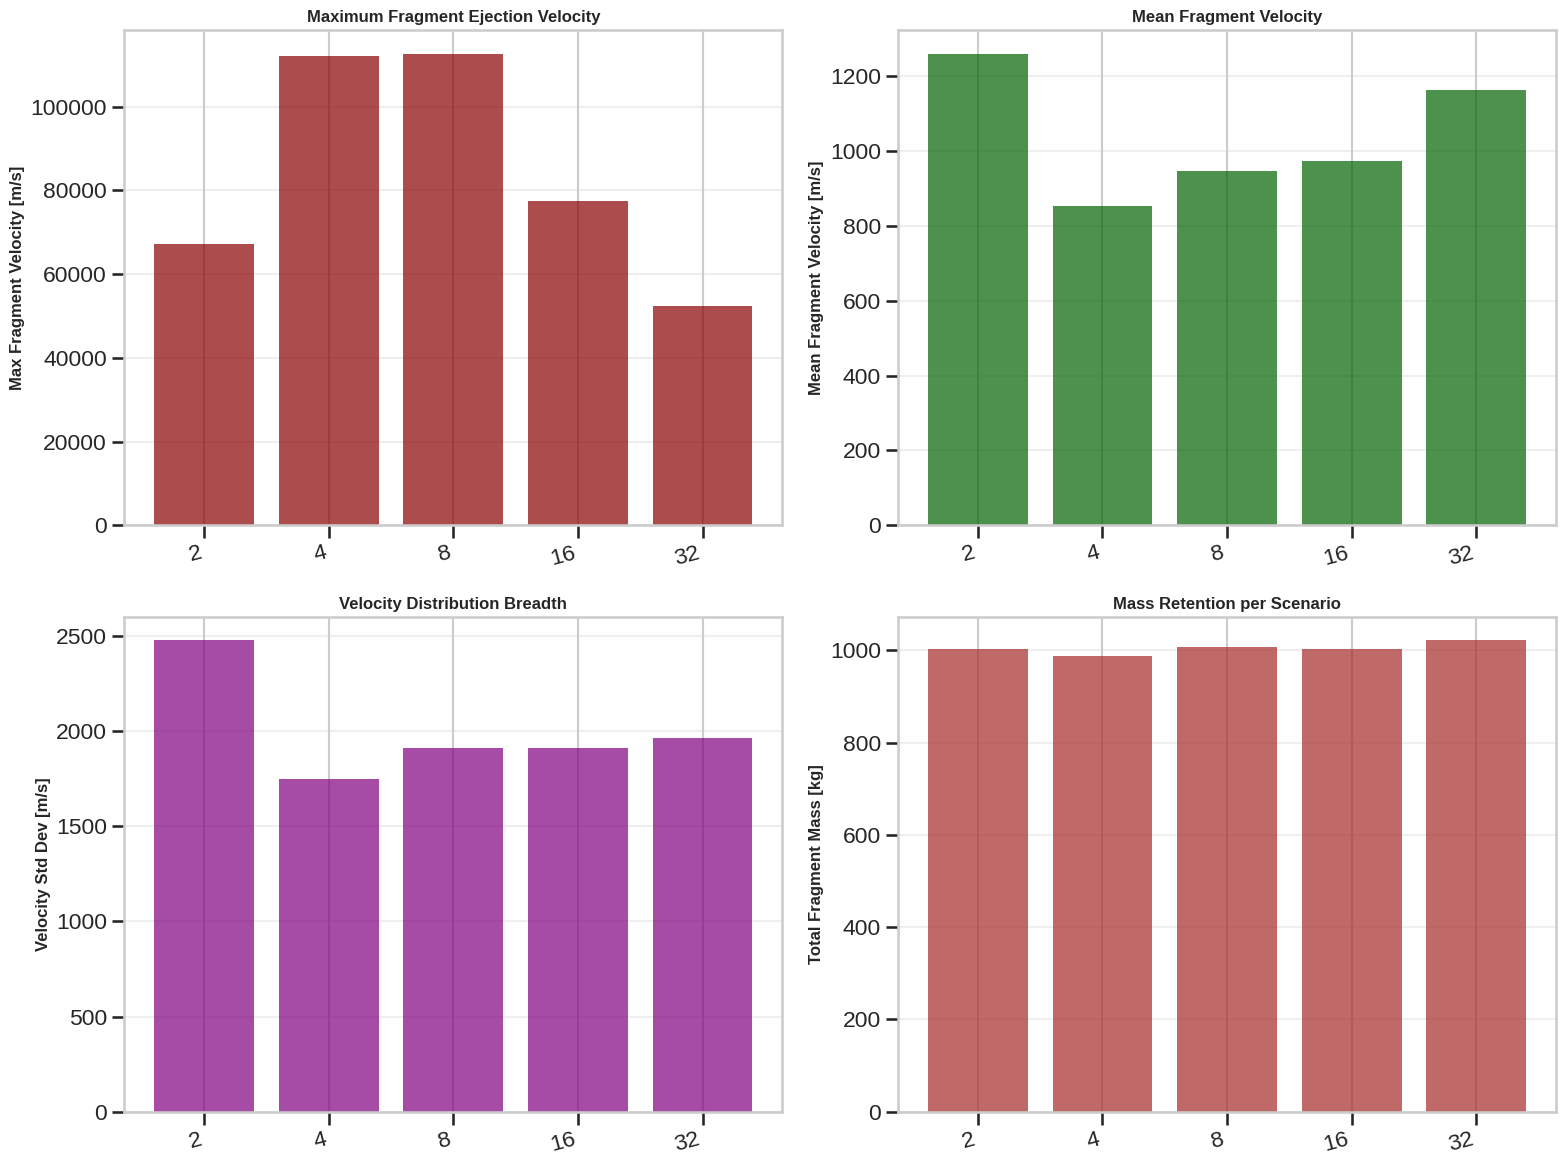


ENERGY METRICS SUMMARY

2:
  Max velocity: 67116.66 m/s
  Mean velocity: 1259.5 m/s ±2474.5 m/s
  Total mass: 1002.00 kg
  Fragment count: 4945

4:
  Max velocity: 112062.35 m/s
  Mean velocity: 852.7 m/s ±1746.1 m/s
  Total mass: 987.69 kg
  Fragment count: 63626

8:
  Max velocity: 112631.16 m/s
  Mean velocity: 945.6 m/s ±1909.3 m/s
  Total mass: 1007.99 kg
  Fragment count: 24928

16:
  Max velocity: 77563.99 m/s
  Mean velocity: 973.9 m/s ±1910.8 m/s
  Total mass: 1002.63 kg
  Fragment count: 53822

32:
  Max velocity: 52441.47 m/s
  Mean velocity: 1162.9 m/s ±1959.6 m/s
  Total mass: 1021.29 kg
  Fragment count: 40774


In [5]:

# Energy metrics across scenarios
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use the actual keys from our loaded data
scenario_labels = list(velocity_data.keys())

# Prepare metrics arrays
max_velocities = []
mean_velocities = []
velocity_std = []
mass_retention = []

for label in scenario_labels:
    df = velocity_data[label]
    if 'Velocity_norm' in df.columns:
        max_velocities.append(df['Velocity_norm'].max())
        mean_velocities.append(df['Velocity_norm'].mean())
        velocity_std.append(df['Velocity_norm'].std())
        
        if 'Mass [kg]' in df.columns:
            mass_retention.append(df['Mass [kg]'].sum())
        else:
            mass_retention.append(0)
    else:
        max_velocities.append(0)
        mean_velocities.append(0)
        velocity_std.append(0)
        mass_retention.append(0)

# Subplot 1: Max fragment velocity
ax = axes[0, 0]
ax.bar(scenario_labels, max_velocities, color='darkred', alpha=0.7, label='Max ejection velocity')
ax.set_ylabel('Max Fragment Velocity [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Maximum Fragment Ejection Velocity', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 2: Mean fragment velocity
ax = axes[0, 1]
ax.bar(scenario_labels, mean_velocities, color='darkgreen', alpha=0.7, label='Mean fragment velocity')
ax.set_ylabel('Mean Fragment Velocity [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Mean Fragment Velocity', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 3: Velocity distribution spread (std dev)
ax = axes[1, 0]
ax.bar(scenario_labels, velocity_std, color='purple', alpha=0.7, label='Velocity std dev')
ax.set_ylabel('Velocity Std Dev [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Velocity Distribution Breadth', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 4: Mass retention
ax = axes[1, 1]
ax.bar(scenario_labels, mass_retention, color='brown', alpha=0.7, label='Total fragment mass')
ax.set_ylabel('Total Fragment Mass [kg]', fontsize=12, fontweight='bold')
ax.set_title('Mass Retention per Scenario', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
save_figure(fig, 'scenario_comparison_metrics')
plt.show()

print("\n" + "="*80)
print("ENERGY METRICS SUMMARY")
print("="*80)
for label in scenario_labels:
    stats_val = velocity_stats[label]
    print(f"\n{label.upper()}:")
    print(f"  Max velocity: {stats_val['max_vel']:.2f} m/s")
    print(f"  Mean velocity: {stats_val['mean_vel']:.1f} m/s ±{stats_val['std_vel']:.1f} m/s")
    print(f"  Total mass: {stats_val['total_mass']:.2f} kg")
    print(f"  Fragment count: {stats_val['count']}")

Saved: fragment_allocation_generalized.png


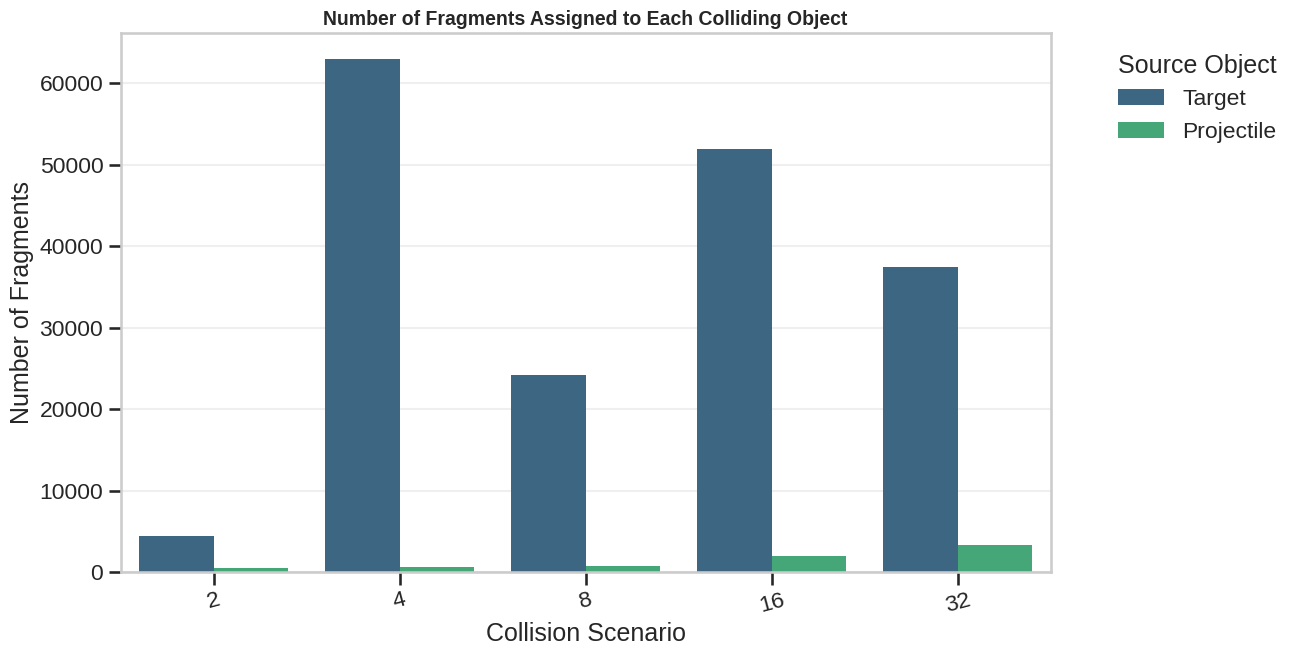

In [6]:
import re

# 1. Fragment Allocation (Generalized for Satellite/Target/Projectile)
plt.figure(figsize=(12, 7))

all_counts = []
for label, df in output_data.items():
    def identify_parent(name):
        # Split by '(' or '-' to get the base name (e.g., "Satellite 1", "Target")
        # Then strip whitespace
        parts = re.split(r'[\(\-]', str(name))
        return parts[0].strip()

    df['Parent_Object'] = df['Name'].apply(identify_parent)
    counts = df['Parent_Object'].value_counts().reset_index()
    counts.columns = ['Parent', 'Count']
    counts['Scenario'] = label
    all_counts.append(counts)

df_counts = pd.concat(all_counts)

# Plotting
sns.barplot(data=df_counts, x='Scenario', y='Count', hue='Parent', palette="viridis")
plt.title("Number of Fragments Assigned to Each Colliding Object", fontsize=14, fontweight='bold')
plt.ylabel("Number of Fragments")
plt.xlabel("Collision Scenario")
plt.xticks(rotation=15)
plt.legend(title="Source Object", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

save_figure(plt.gcf(), 'fragment_allocation_generalized')
plt.show()

Saved: velocity_distribution_kde.png


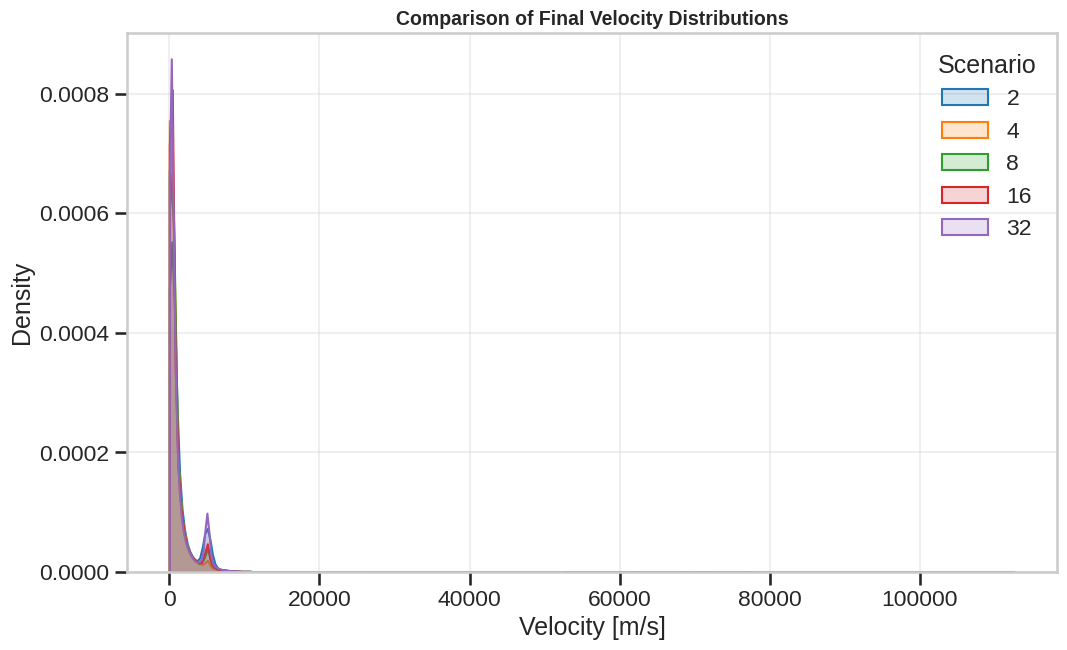

In [7]:
# 2. Final Velocity Distribution
plt.figure(figsize=(12, 7))

for label, df in output_data.items():
    sns.kdeplot(data=df, x="Velocity_norm", label=label, fill=True, alpha=0.2, cut=0)

plt.title("Comparison of Final Velocity Distributions", fontsize=14, fontweight='bold')
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend(title="Scenario")
plt.grid(True, alpha=0.3)

save_figure(plt.gcf(), 'velocity_distribution_kde')
plt.show()

Saved: mass_distribution_log.png


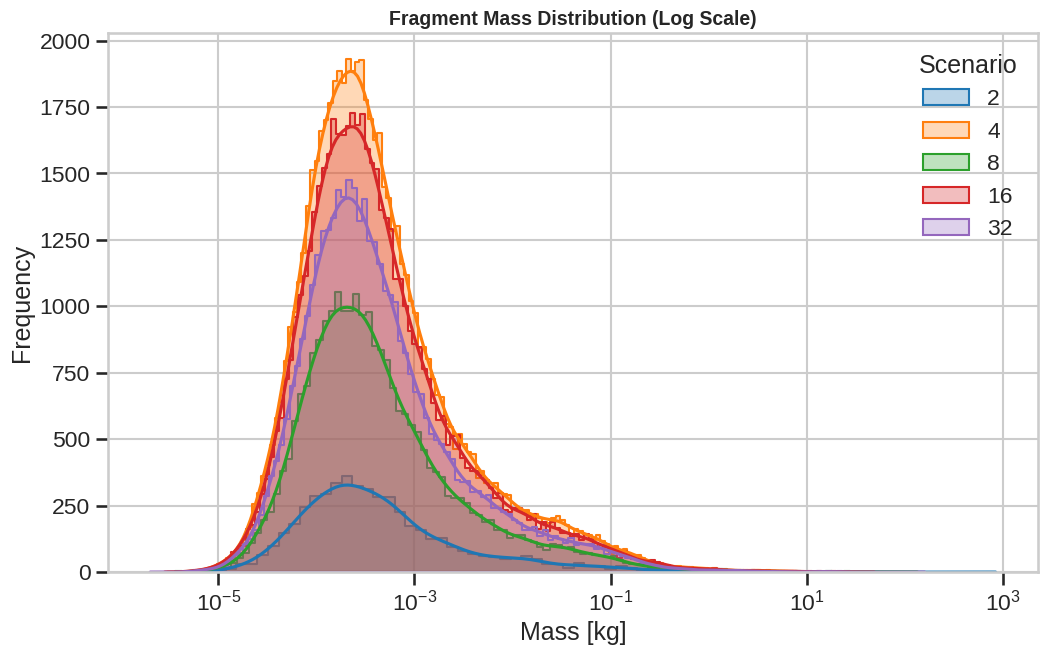

In [8]:
# 3. Mass Distribution
plt.figure(figsize=(12, 7))

for label, df in output_data.items():
    # Filter for positive mass to avoid log errors
    valid_mass = df[df['Mass [kg]'] > 0]
    sns.histplot(data=valid_mass, x="Mass [kg]", label=label, kde=True, 
                 element="step", log_scale=True, alpha=0.3)

plt.title("Fragment Mass Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Mass [kg]")
plt.ylabel("Frequency")
plt.legend(title="Scenario")

save_figure(plt.gcf(), 'mass_distribution_log')
plt.show()

Saved: length_distribution_log.png


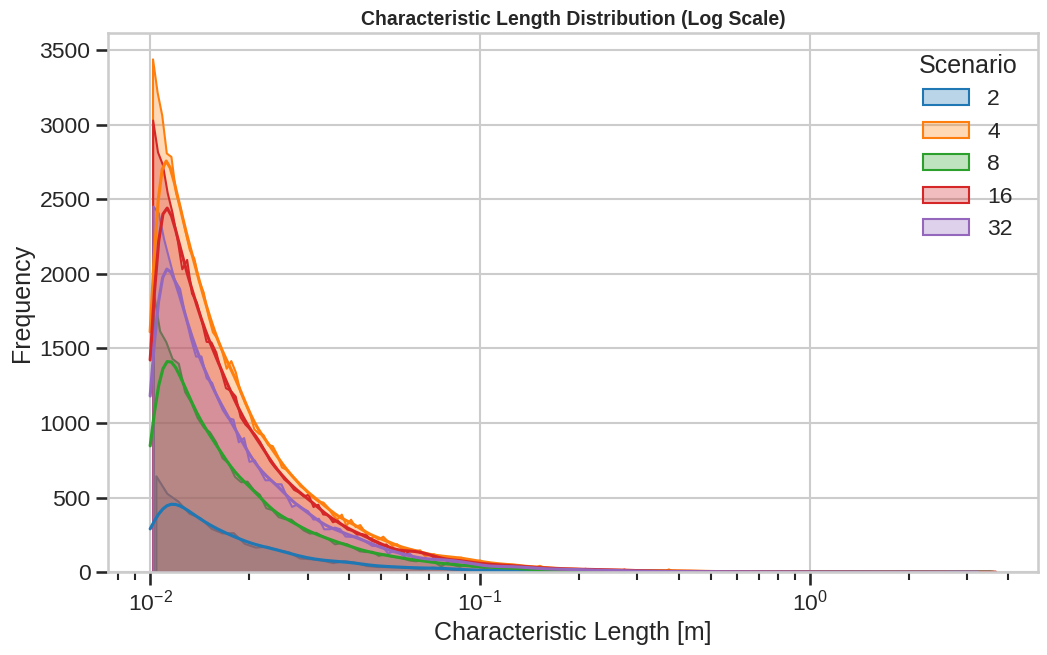

In [9]:
# 4. Characteristic Length Distribution
plt.figure(figsize=(12, 7))

col_len = "Characteristic Length [m]"

for label, df in output_data.items():
    if col_len in df.columns:
        valid_len = df[df[col_len] > 0]
        sns.histplot(data=valid_len, x=col_len, label=label, kde=True, 
                     element="poly", log_scale=True, alpha=0.3)

plt.title("Characteristic Length Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Frequency")
plt.legend(title="Scenario")

save_figure(plt.gcf(), 'length_distribution_log')
plt.show()

2: Max Characteristic Length = 3.5337697951517963 m
4: Max Characteristic Length = 2.6042801528039896 m
8: Max Characteristic Length = 3.595848635762517 m
16: Max Characteristic Length = 3.6591390807599655 m
32: Max Characteristic Length = 3.2252772156305527 m


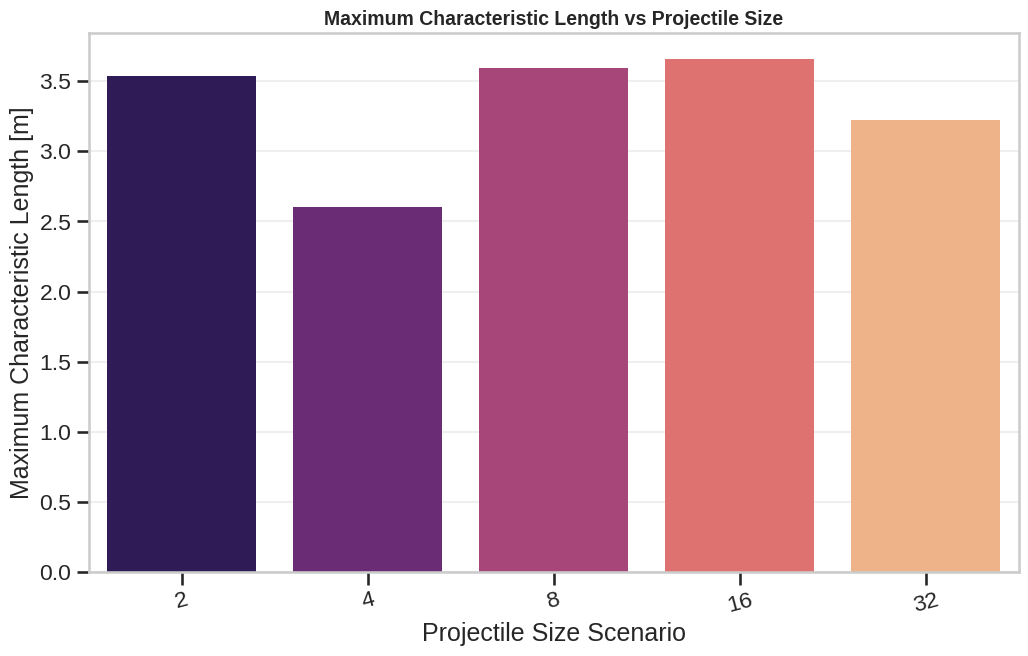

In [10]:
# 5. Maximum Characteristic length vs Projectile Size
plt.figure(figsize=(12, 7))
min_lengths = []
for label, df in output_data.items():
    # 1. CLEANING: Strip any hidden spaces from column names
    df.columns = df.columns.str.strip()
    
    col_len = "Characteristic Length [m]"
    
    if col_len in df.columns:
        # 2. DEBUG: Verify the first few values to ensure they look like lengths (e.g., 0.01), not A/M (e.g., 0.09)
        # print(f"DEBUG {label} - First 2 lengths: {df[col_len].head(2).values}")
        
        # 3. CONVERSION: Ensure numeric type (handles potential empty strings/corrupt rows)
        df[col_len] = pd.to_numeric(df[col_len], errors='coerce')
        
        max_len = df[col_len].max()
        min_lengths.append((label, max_len))
        print(f"{label}: Max Characteristic Length = {max_len} m")
    else:
        # 4. ROBUSTNESS: If the name match fails, you can try selecting by index 
        # (Based on your CSV, Char Length is index 3 if ID is col 0)
        try:
            alt_col = df.iloc[:, 3]
            max_len = pd.to_numeric(alt_col, errors='coerce').max()
            min_lengths.append((label, max_len))
            print(f"{label}: Column name not found, using index 3. Max = {max_len:.2e} m")
        except Exception as e:
            min_lengths.append((label, 0))
            print(f"{label}: Column not found and index access failed.")

# Plotting
if min_lengths:
    labels, min_len_values = zip(*min_lengths)
    sns.barplot(x=list(labels), y=list(min_len_values), palette="magma")
    plt.title("Maximum Characteristic Length vs Projectile Size", fontsize=14, fontweight='bold')
    plt.xlabel("Projectile Size Scenario")
    plt.ylabel("Maximum Characteristic Length [m]")
    plt.xticks(rotation=15)
    plt.grid(axis='y', alpha=0.3)

2: Min Characteristic Length = 0.0100012264951693 m
4: Min Characteristic Length = 0.0100000567803067 m
8: Min Characteristic Length = 0.0100006178983183 m
16: Min Characteristic Length = 0.0100002711950438 m
32: Min Characteristic Length = 0.0100002467736488 m


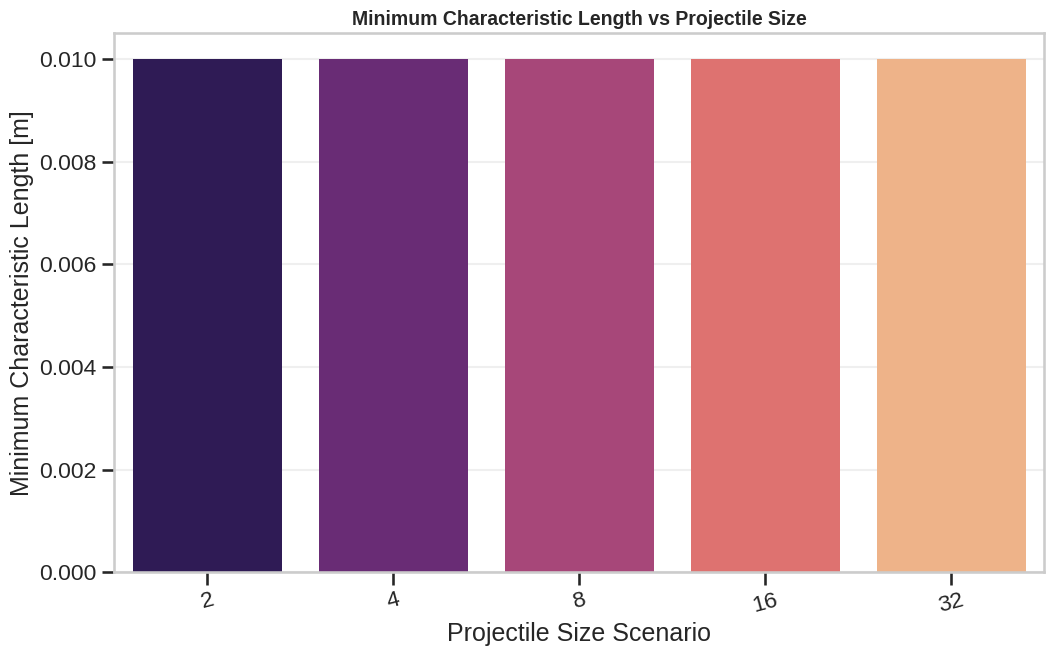

In [11]:
# 6. Minimum Characteristic length vs Projectile Size
plt.figure(figsize=(12, 7))
min_lengths = []
for label, df in output_data.items():
    # 1. CLEANING: Strip any hidden spaces from column names
    df.columns = df.columns.str.strip()
    
    col_len = "Characteristic Length [m]"
    
    if col_len in df.columns:
        # 2. DEBUG: Verify the first few values to ensure they look like lengths (e.g., 0.01), not A/M (e.g., 0.09)
        # print(f"DEBUG {label} - First 2 lengths: {df[col_len].head(2).values}")
        
        # 3. CONVERSION: Ensure numeric type (handles potential empty strings/corrupt rows)
        df[col_len] = pd.to_numeric(df[col_len], errors='coerce')
        
        min_len = df[col_len].min()
        min_lengths.append((label, min_len))
        print(f"{label}: Min Characteristic Length = {min_len} m")
    else:
        # 4. ROBUSTNESS: If the name match fails, you can try selecting by index 
        # (Based on your CSV, Char Length is index 3 if ID is col 0)
        try:
            alt_col = df.iloc[:, 3]
            min_len = pd.to_numeric(alt_col, errors='coerce').min()
            min_lengths.append((label, min_len))
            print(f"{label}: Column name not found, using index 3. Min = {min_len:.2e} m")
        except Exception as e:
            min_lengths.append((label, 0))
            print(f"{label}: Column not found and index access failed.")

# Plotting
if min_lengths:
    labels, min_len_values = zip(*min_lengths)
    sns.barplot(x=list(labels), y=list(min_len_values), palette="magma")
    plt.title("Minimum Characteristic Length vs Projectile Size", fontsize=14, fontweight='bold')
    plt.xlabel("Projectile Size Scenario")
    plt.ylabel("Minimum Characteristic Length [m]")
    plt.xticks(rotation=15)
    plt.grid(axis='y', alpha=0.3)

In [12]:
input_files = {
    '2': '../../input/0.0002_input.csv',
    '4': '../../input/0.0004_input.csv',
    '8': '../../input/0.0008_input.csv',
    '16': '../../input/0.0016_input.csv',
    '32': '../../input/0.0032_input.csv',
}

input_data = {}
for label, filename in input_files.items():
    df = load_and_process_result(filename)
    if df is not None:
        input_data[label] = df
        print(f"✓ Loaded {label}: {len(df)} fragments")
    else:
        print(f"✗ Failed to load {label}")

✓ Loaded 2: 2 fragments
✓ Loaded 4: 2 fragments
✓ Loaded 8: 2 fragments
✓ Loaded 16: 2 fragments
✓ Loaded 32: 2 fragments


In [13]:
# 7. Check Charachteristic Length sum conservation between input and output

for label, df in output_data.items():
    df.columns = df.columns.str.strip()
    col_len = "Characteristic Length [m]"
    if col_len in df.columns:
        total_length = df[col_len].sum()
        print(f"{label}: Total Characteristic Length = {total_length:.2e} m")
    else:
        print(f"{label}: Characteristic Length column not found.")
for label, df in input_data.items():
    df.columns = df.columns.str.strip()
    col_len = "Characteristic Length [m]"
    if col_len in df.columns:
        total_length = df[col_len].sum()
        print(f"{label} (input): Total Characteristic Length = {total_length:.2e} m")
    else:
        print(f"{label} (input): Characteristic Length column not found.")


        

2: Total Characteristic Length = 1.27e+02 m
4: Total Characteristic Length = 1.50e+03 m
8: Total Characteristic Length = 6.16e+02 m
16: Total Characteristic Length = 1.28e+03 m
32: Total Characteristic Length = 9.69e+02 m
2 (input): Total Characteristic Length = 4.05e+00 m
4 (input): Total Characteristic Length = 4.14e+00 m
8 (input): Total Characteristic Length = 4.26e+00 m
16 (input): Total Characteristic Length = 4.42e+00 m
32 (input): Total Characteristic Length = 4.64e+00 m


In [14]:
# 8. Check Mass sum conservation between input and output
for label, df in output_data.items():
    df.columns = df.columns.str.strip()
    col_mass = "Mass [kg]"
    if col_mass in df.columns:
        total_mass = df[col_mass].sum()
        print(f"{label}: Total Mass = {total_mass:.2f} kg")
    else:
        print(f"{label}: Mass column not found.")
for label, df in input_data.items():
    df.columns = df.columns.str.strip()
    col_mass = "Mass [kg]"
    if col_mass in df.columns:
        total_mass = df[col_mass].sum()
        print(f"{label} (input): Total Mass = {total_mass:.2f} kg")
    else:
        print(f"{label} (input): Mass column not found.")

2: Total Mass = 1002.00 kg
4: Total Mass = 987.69 kg
8: Total Mass = 1007.99 kg
16: Total Mass = 1002.63 kg
32: Total Mass = 1021.29 kg
2 (input): Total Mass = 1002.00 kg
4 (input): Total Mass = 1004.00 kg
8 (input): Total Mass = 1008.00 kg
16 (input): Total Mass = 1016.00 kg
32 (input): Total Mass = 1032.00 kg
